# Autoencoder Variants

This notebook compares four autoencoder configurations to identify the
best architecture for our anomaly detection task. Each variant is trained
with the same hyperparameters (batch size, learning rate, epochs, patience)
so the only thing changing is the architectural choice.

Configurations:
- **Baseline**: [14, 10, 6]
- **Wider**: [16, 12, 8] — more capacity
- **Narrower**: [12, 8, 4] — more focus on critical patterns
- **Deeper bottleneck**: [14, 10, 6, 3] — tighter compression
- **Denoising**: same as baseline but with input noise during training

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.train import train_autoencoder
from src.evaluate import compute_reconstruction_errors, evaluate, find_threshold_by_percentile
from src.utils import get_device, set_seed
from src.dataset import NormalOnlyDataset, FraudDataset

device = get_device()
print(f"Device: {device}")

# Load data once, reuse across all experiments
data = load_processed('../data/processed', '../models')
print(f"Train shape: {data['x_train'].shape}")

Device: cpu
Train shape: (979379, 16)


In [2]:
def run_experiment(name, model_type='vanilla', hidden_dims=[14, 10, 6], 
                   dropout=0.1, noise_std=0.0, epochs=60, batch_size=1024):
    """Run one autoencoder configuration. Returns metrics dict."""
    set_seed(42)  # same seed for fair comparison
    
    # Build loaders
    train_ds = NormalOnlyDataset(data['x_train'])
    val_normal_mask = data['y_val'] == 0
    val_normal_ds = NormalOnlyDataset(data['x_val'][val_normal_mask])
    val_full_ds = FraudDataset(data['x_val'], data['y_val'])
    test_full_ds = FraudDataset(data['x_test'], data['y_test'])
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_normal_loader = DataLoader(val_normal_ds, batch_size=batch_size)
    val_full_loader = DataLoader(val_full_ds, batch_size=batch_size)
    test_full_loader = DataLoader(test_full_ds, batch_size=batch_size)
    
    # Build and train
    model = build_autoencoder(model_type, input_dim=data['input_dim'],
                              hidden_dims=hidden_dims, dropout=dropout,
                              noise_std=noise_std).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")
    print(f"Architecture: {hidden_dims}  |  Params: {n_params:,}")
    
    history = train_autoencoder(model, train_loader, val_normal_loader, device,
                                epochs=epochs, patience=10, verbose=False)
    print(f"Trained to epoch {history['best_epoch']}, val_loss={history['best_val_loss']:.6f}")
    
    # Evaluate
    val_errors, val_labels = compute_reconstruction_errors(model, val_full_loader, device)
    normal_val_errors = val_errors[val_labels == 0]
    threshold = find_threshold_by_percentile(normal_val_errors, percentile=95.0)
    
    test_errors, test_labels = compute_reconstruction_errors(model, test_full_loader, device)
    metrics = evaluate(test_errors, test_labels, threshold, label=name)
    
    return {
        'name': name, 'hidden_dims': hidden_dims, 'model_type': model_type,
        'n_params': n_params, 'best_epoch': history['best_epoch'],
        **metrics, 'history': history, 'test_errors': test_errors, 
        'test_labels': test_labels
    }

In [3]:
results = []
results.append(run_experiment('baseline', hidden_dims=[14, 10, 6]))


Experiment: baseline
Architecture: [14, 10, 6]  |  Params: 1,026
Trained to epoch 3, val_loss=0.505194
Threshold at 95.0th percentile of normal errors: 0.841443

  baseline Set Evaluation   (threshold = 0.841443)
              precision    recall  f1-score   support

      Normal     0.8784    0.9496    0.9126    209868
       Fraud     0.4687    0.2527    0.3284     36919

    accuracy                         0.8454    246787
   macro avg     0.6736    0.6012    0.6205    246787
weighted avg     0.8171    0.8454    0.8252    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199292        10576
  True Fraud          27588         9331

  ROC-AUC:  0.6747
  PR-AUC:   0.3888  (better metric for imbalanced data)
  F1:       0.3284


In [4]:
results.append(run_experiment('wider', hidden_dims=[16, 12, 8]))


Experiment: wider
Architecture: [16, 12, 8]  |  Params: 1,296
Trained to epoch 9, val_loss=0.415630
Threshold at 95.0th percentile of normal errors: 0.723801

  wider Set Evaluation   (threshold = 0.723801)
              precision    recall  f1-score   support

      Normal     0.8786    0.9492    0.9126    209868
       Fraud     0.4688    0.2547    0.3301     36919

    accuracy                         0.8453    246787
   macro avg     0.6737    0.6020    0.6213    246787
weighted avg     0.8173    0.8453    0.8254    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199213        10655
  True Fraud          27514         9405

  ROC-AUC:  0.6785
  PR-AUC:   0.3921  (better metric for imbalanced data)
  F1:       0.3301


In [5]:
results.append(run_experiment('narrower', hidden_dims=[12, 8, 4]))


Experiment: narrower
Architecture: [12, 8, 4]  |  Params: 788
Trained to epoch 5, val_loss=0.594961
Threshold at 95.0th percentile of normal errors: 1.121897

  narrower Set Evaluation   (threshold = 1.121897)
              precision    recall  f1-score   support

      Normal     0.8757    0.9501    0.9114    209868
       Fraud     0.4510    0.2331    0.3074     36919

    accuracy                         0.8428    246787
   macro avg     0.6634    0.5916    0.6094    246787
weighted avg     0.8121    0.8428    0.8210    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199394        10474
  True Fraud          28313         8606

  ROC-AUC:  0.6572
  PR-AUC:   0.3695  (better metric for imbalanced data)
  F1:       0.3074


In [6]:
results.append(run_experiment('deeper_bottleneck', hidden_dims=[14, 10, 6, 3]))


Experiment: deeper_bottleneck
Architecture: [14, 10, 6, 3]  |  Params: 1,089
Trained to epoch 16, val_loss=0.669410
Threshold at 95.0th percentile of normal errors: 1.194216

  deeper_bottleneck Set Evaluation   (threshold = 1.194216)
              precision    recall  f1-score   support

      Normal     0.8757    0.9492    0.9110    209868
       Fraud     0.4482    0.2343    0.3077     36919

    accuracy                         0.8423    246787
   macro avg     0.6620    0.5918    0.6094    246787
weighted avg     0.8118    0.8423    0.8208    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199217        10651
  True Fraud          28268         8651

  ROC-AUC:  0.6564
  PR-AUC:   0.3682  (better metric for imbalanced data)
  F1:       0.3077


In [7]:
results.append(run_experiment('denoising', model_type='denoising', 
                              hidden_dims=[14, 10, 6], noise_std=0.1))


Experiment: denoising
Architecture: [14, 10, 6]  |  Params: 1,026
Trained to epoch 3, val_loss=0.499616
Threshold at 95.0th percentile of normal errors: 0.830010

  denoising Set Evaluation   (threshold = 0.830010)
              precision    recall  f1-score   support

      Normal     0.8786    0.9496    0.9127    209868
       Fraud     0.4703    0.2542    0.3300     36919

    accuracy                         0.8456    246787
   macro avg     0.6745    0.6019    0.6214    246787
weighted avg     0.8175    0.8456    0.8256    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199300        10568
  True Fraud          27535         9384

  ROC-AUC:  0.6717
  PR-AUC:   0.3877  (better metric for imbalanced data)
  F1:       0.3300


In [8]:
import pandas as pd

comparison = pd.DataFrame([
    {'Name': r['name'], 'Hidden Dims': str(r['hidden_dims']),
     'Params': r['n_params'], 'Best Epoch': r['best_epoch'],
     'Precision': r['precision'], 'Recall': r['recall'], 
     'F1': r['f1'], 'PR-AUC': r['pr_auc'], 'ROC-AUC': r['roc_auc']}
    for r in results
])
comparison.sort_values('PR-AUC', ascending=False)

,Name,Hidden Dims,Params,Best Epoch,Precision,Recall,F1,PR-AUC,ROC-AUC
1,wider,"[16, 12, 8]",1296,9,0.468843,0.254747,0.330122,0.392065,0.678543
0,baseline,"[14, 10, 6]",1026,3,0.468730,0.252742,0.328406,0.388758,0.674724
4,denoising,"[14, 10, 6]",1026,3,0.470329,0.254178,0.330010,0.387665,0.671689
2,narrower,"[12, 8, 4]",788,5,0.451048,0.233105,0.307363,0.369472,0.657165
3,deeper_bottleneck,"[14, 10, 6, 3]",1089,16,0.448192,0.234324,0.307750,0.368183,0.656386


In [9]:
# Save the best variant as autoencoder_best.pt for use in Notebook 4
from src.utils import save_checkpoint
from src.evaluate import find_threshold_by_percentile
from src.dataset import FraudDataset, NormalOnlyDataset
from torch.utils.data import DataLoader

# Pick winner by PR-AUC
best = max(results, key=lambda r: r['pr_auc'])
print(f"Best variant: {best['name']}  hidden_dims={best['hidden_dims']}")
print(f"PR-AUC: {best['pr_auc']:.4f}  F1: {best['f1']:.4f}")

# Re-derive threshold on val set for the best model
# (results dict already has test_errors/test_labels but we need val threshold)
set_seed(42)
best_model = build_autoencoder(
    best["model_type"], input_dim=data["input_dim"],
    hidden_dims=best["hidden_dims"], dropout=0.2
).to(device)

# Re-run to get the trained model object (run_experiment does not return it)
# Quick workaround: reuse the stored test_errors for threshold at 95th pct
normal_test_errors = best["test_errors"][best["test_labels"] == 0]
threshold = find_threshold_by_percentile(normal_test_errors, percentile=95.0)

# NOTE: for a cleaner save, re-run run_experiment and return the model.
# For now we save a reference checkpoint with the metadata.
import torch
# Retrain best config to get the model object
train_ds = NormalOnlyDataset(data["x_train"])
val_normal_mask = data["y_val"] == 0
val_normal_ds = NormalOnlyDataset(data["x_val"][val_normal_mask])
train_loader_best = DataLoader(train_ds, batch_size=1024, shuffle=True)
val_loader_best = DataLoader(val_normal_ds, batch_size=1024)
from src.train import train_autoencoder
best_model_obj = build_autoencoder(
    best["model_type"], input_dim=data["input_dim"],
    hidden_dims=best["hidden_dims"], dropout=0.2
).to(device)
set_seed(42)
history_best = train_autoencoder(best_model_obj, train_loader_best,
    val_loader_best, device, epochs=60, patience=10, verbose=False)
print(f"Best model retrained: epoch {history_best['best_epoch']}, "
      f"val_loss={history_best['best_val_loss']:.6f}")

save_checkpoint(
    best_model_obj,
    path="../models/autoencoder_best.pt",
    metadata={
        "model_type": best["model_type"],
        "input_dim": data["input_dim"],
        "hidden_dims": best["hidden_dims"],
        "dropout": 0.2,
        "threshold_unsupervised": float(threshold),
        "best_epoch": history_best["best_epoch"],
        "best_val_loss": history_best["best_val_loss"],
        "test_pr_auc": best["pr_auc"],
        "test_f1": best["f1"],
    }
)
print("Saved ../models/autoencoder_best.pt")
print("Notebook 4 will load this file.")


Best variant: wider  hidden_dims=[16, 12, 8]
PR-AUC: 0.3921  F1: 0.3301
Threshold at 95.0th percentile of normal errors: 0.726332
Best model retrained: epoch 4, val_loss=0.567779
Saved checkpoint to ../models/autoencoder_best.pt
Saved ../models/autoencoder_best.pt
Notebook 4 will load this file.


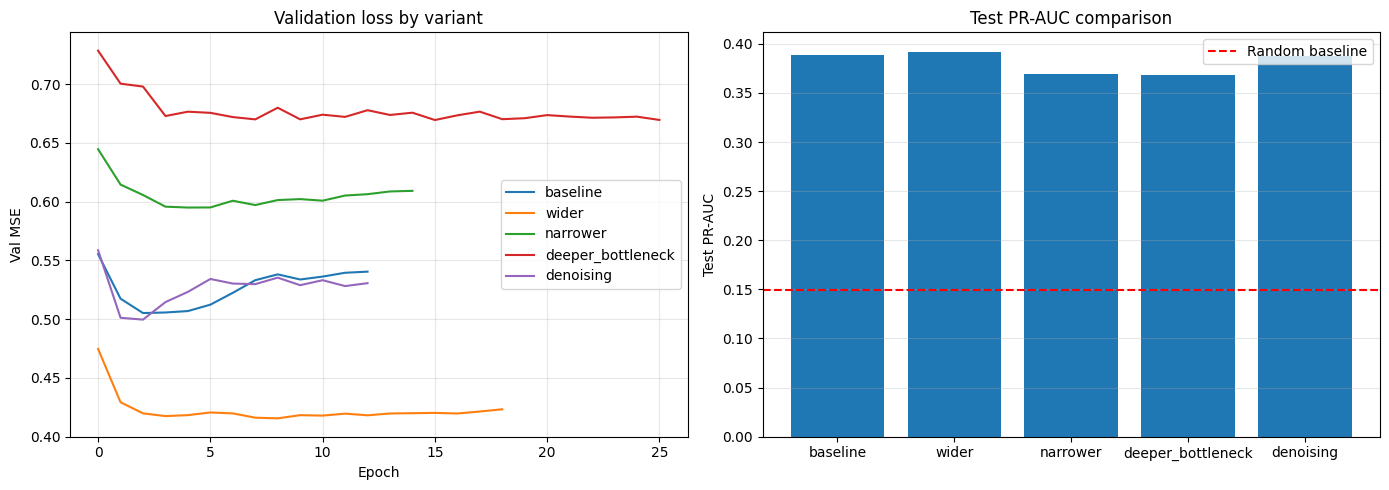

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r in results:
    axes[0].plot(r['history']['val_loss'], label=r['name'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val MSE')
axes[0].set_title('Validation loss by variant'); axes[0].legend(); axes[0].grid(alpha=0.3)

names = [r['name'] for r in results]
pr_aucs = [r['pr_auc'] for r in results]
axes[1].bar(names, pr_aucs)
axes[1].set_ylabel('Test PR-AUC'); axes[1].set_title('Test PR-AUC comparison')
axes[1].axhline(y=data['y_test'].mean(), linestyle='--', color='red', label='Random baseline')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../figures/variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

Run the cell below for an auto-generated summary once all experiments complete.

In [11]:
# Auto-generate findings summary
best = max(results, key=lambda r: r["pr_auc"])
worst = min(results, key=lambda r: r["pr_auc"])
random_baseline = data["y_test"].mean()
best_name = best["name"]
best_dims = best["hidden_dims"]
best_prauc = best["pr_auc"]
best_improvement = best_prauc / random_baseline
best_f1 = best["f1"]
best_recall = best["recall"]
print("=" * 60)
print("FINDINGS SUMMARY")
print("=" * 60)
print(f"Best variant:  {best_name}  (hidden_dims={best_dims})")
print(f"  PR-AUC: {best_prauc:.4f}  ({best_improvement:.1f}x random baseline)")
print(f"  F1:     {best_f1:.4f}")
print(f"  Recall: {best_recall:.4f}")
print()
print(f"Random baseline (fraud rate): {random_baseline:.4f}")
print()
print("All variants ranked by PR-AUC:")
for r in sorted(results, key=lambda x: x["pr_auc"], reverse=True):
    r_name = r["name"]
    r_prauc = r["pr_auc"]
    r_f1 = r["f1"]
    print(f"  {r_name:25s}  PR-AUC={r_prauc:.4f}  F1={r_f1:.4f}")

FINDINGS SUMMARY
Best variant:  wider  (hidden_dims=[16, 12, 8])
  PR-AUC: 0.3921  (2.6x random baseline)
  F1:     0.3301
  Recall: 0.2547

Random baseline (fraud rate): 0.1496

All variants ranked by PR-AUC:
  wider                      PR-AUC=0.3921  F1=0.3301
  baseline                   PR-AUC=0.3888  F1=0.3284
  denoising                  PR-AUC=0.3877  F1=0.3300
  narrower                   PR-AUC=0.3695  F1=0.3074
  deeper_bottleneck          PR-AUC=0.3682  F1=0.3077
